In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
sns.set()
%matplotlib inline
import warnings
warnings.filterwarnings('ignore')
import re
from bs4 import BeautifulSoup
from collections import Counter
import nltk
from nltk.corpus import stopwords
from nltk.stem import WordNetLemmatizer
from nltk.tokenize import word_tokenize
from wordcloud import WordCloud
import spacy
from spacy import displacy
import joblib

from sklearn.model_selection import train_test_split
from sklearn.pipeline import Pipeline
from sklearn.feature_extraction.text import TfidfVectorizer, CountVectorizer
from sklearn.naive_bayes import MultinomialNB
from sklearn.svm import SVC
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report, confusion_matrix
from sklearn.model_selection import GridSearchCV
from sklearn.utils import resample

# For deep learning with TensorFlow
import tensorflow as tf
from tensorflow.keras.preprocessing.text import Tokenizer
from tensorflow.keras.layers import Embedding, Dropout
from tensorflow.keras.preprocessing.sequence import pad_sequences
from tensorflow.keras.models import Sequential
from tensorflow.keras.optimizers import Adam, RMSprop
from tensorflow.keras.preprocessing.text import one_hot
from tensorflow.keras.layers import LSTM
from tensorflow.keras.utils import to_categorical
from tensorflow.keras.layers import Dense, Bidirectional
from tensorflow.keras.callbacks import EarlyStopping

import warnings
warnings.filterwarnings("ignore")

In [ ]:
nltk.download('wordnet')
nltk.download('stopwords')
nltk.download('punkt_tab')

[nltk_data] Downloading package wordnet to /root/nltk_data...
[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Unzipping corpora/stopwords.zip.
[nltk_data] Downloading package punkt_tab to /root/nltk_data...
[nltk_data]   Unzipping tokenizers/punkt_tab.zip.


True

In [ ]:
df = pd.read_csv("/content/drive/MyDrive/capstone/prime_videos.csv", encoding='ISO-8859-1')

In [ ]:
df.head(3)

,rating,title_x,text,asin,parent_asin,timestamp,verified_purchase,main_category,title_y,average_rating,rating_number,description,price,categories
0,5,Five Stars,"Amazon, please buy the show! I'm hooked!",B013488XFS,B013488XFS,2015-08-24 03:07:17.000,True,Prime Video,Sneaky Pete,4.6,56658.0,['A\xa0con man (Giovanni Ribisi) on the run fr...,NaN,Suspense
1,5,Five Stars,My Kiddos LOVE this show!!,B00CB6VTDS,B00CB6VTDS,2016-04-19 21:16:50.000,True,Prime Video,Creative Galaxy,4.8,6403.0,['Follow the adventures of Arty and his sideki...,NaN,Kids
2,5,What Love Is...,"...isn't always how you expect it to be, but w...",B001H1SVZC,B001H1SVZC,2020-05-28 04:13:47.074,True,Prime Video,NaN,4.5,389.0,NaN,NaN,NaN


In [ ]:
df = df[['rating', 'title_x', 'text']]
df.head()

,rating,title_x,text
0,5,Five Stars,"Amazon, please buy the show! I'm hooked!"
1,5,Five Stars,My Kiddos LOVE this show!!
2,5,What Love Is...,"...isn't always how you expect it to be, but w..."
3,5,QUIRKY TURNS TO HEARTSTRINGS,As you learn about the very unique characters ...
4,5,Way better than the harsh reviews.,Our family loved the film. We have kids and th...


In [ ]:
df.isna().sum()

,0
rating,0
title_x,24
text,31


In [ ]:
df.duplicated().sum()

np.int64(20573)

In [ ]:
df = df.drop_duplicates()

In [ ]:
df.isna().sum()

,0
rating,0
title_x,15
text,15


In [ ]:
df = df.dropna()
df.shape

(213010, 3)

In [ ]:
data = df.copy()

In [ ]:
# Create 'sentiments' column
def classify_sentiment(rating):
    if rating in [1, 2]:
        return 'negative'
    elif rating == 3:
        return 'neutral'
    elif rating in [4, 5]:
        return 'positive'

data['sentiment'] = data['rating'].apply(classify_sentiment)

In [ ]:
data['reviews'] = data['title_x'] + '  ' + data['text']

In [ ]:
data = data.drop(['title_x', 'text', 'rating'], axis=1)
data.head(3)

,sentiment,reviews
0,positive,"Five Stars Amazon, please buy the show! I'm h..."
1,positive,Five Stars My Kiddos LOVE this show!!
2,positive,What Love Is... ...isn't always how you expec...


In [ ]:
data['sentiment'].value_counts()

,count
sentiment,
positive,158550
negative,32559
neutral,21901


In [ ]:
def strip_html_tags(text):
    soup = BeautifulSoup(text, "html.parser")
    stripped_text = soup.get_text()
    return stripped_text

In [ ]:
data['reviews'] = data['reviews'].apply(strip_html_tags)
data['reviews'][:3]

,reviews
0,"Five Stars Amazon, please buy the show! I'm h..."
1,Five Stars My Kiddos LOVE this show!!
2,What Love Is... ...isn't always how you expec...


In [ ]:
# Define a function for text preprocessing
def preprocess_text(text):
    # Remove numbers
    text = re.sub(r'\d+', '', text)

    # Remove punctuation and symbols
    text = re.sub(r'[^\w\s]', '', text)

    # Convert to lowercase
    text = text.lower()

    # Lemmatize text
    lemmatizer = WordNetLemmatizer()
    text = ' '.join([lemmatizer.lemmatize(word) for word in text.split()])

    # Remove stop words
    stop_words = set(stopwords.words('english'))

    text = ' '.join([word for word in text.split() if word not in stop_words])

    return text

In [ ]:
# Apply the preprocessing function to the 'reviews'
data["clean_review"] = data["reviews"].apply(preprocess_text)

In [ ]:
# verify the changes
data['clean_review'].head()

,clean_review
0,five star amazon please buy show im hooked
1,five star kiddos love show
2,love isnt always expect know movie deep strugg...
3,quirky turn heartstrings learn unique characte...
4,way better harsh review family loved film kid ...


In [ ]:
data = data.reset_index(drop=True)

In [ ]:
# Create an empty corpus list
articles = []

# Append each text entry from the 'clean_review' column to the corpus using a loop.
for entry in data['clean_review']:
    articles.append(entry)

In [ ]:
articles[1]

'five star kiddos love show'

In [ ]:
### Vocabulary size
voc_size=5000

In [ ]:
#onehot_repr
onehot_repr=[one_hot(str(words),voc_size)for words in articles]

In [ ]:
len(onehot_repr[1])

5

In [ ]:
sent_length=30
embedded_docs=pad_sequences(onehot_repr,padding='post',maxlen=sent_length)
print(embedded_docs)

[[4717 2550 2989 ...    0    0    0]
 [4717 2550 2312 ...    0    0    0]
 [1050 1091 3992 ... 3298 2888 3946]
 ...
 [2411 1685  352 ... 3636 1685  312]
 [4560 4563  450 ... 2919 1339 3992]
 [3572 3482 1856 ... 3636 3482 1719]]


In [ ]:
embedded_docs[1]

array([4717, 2550, 2312, 2919, 3188,    0,    0,    0,    0,    0,    0,
          0,    0,    0,    0,    0,    0,    0,    0,    0,    0,    0,
          0,    0,    0,    0,    0,    0,    0,    0], dtype=int32)

In [ ]:
## Creating model
# Define the number of dimensions for the embedding vectors.
# This is the size of the vector that will represent each word.
embedding_vector_features= 40

# Initialize a Sequential model
model=Sequential()

# Add an Embedding layer.
model.add(Embedding(input_dim= voc_size,
                    output_dim= embedding_vector_features,
                    input_length=sent_length))

# Add an LSTM layer with 100 units.
# LSTM (Long Short-Term Memory) helps capture temporal dependencies in sequential data.
model.add(LSTM(100))
model.add(Dropout(0.3))

# Add a Dense layer with a single neuron.
# The 'sigmoid' activation function is used for binary classification.
model.add(Dense(3, activation='softmax'))

# Compile the model.
model.compile(loss='categorical_crossentropy',optimizer='adam',metrics=['accuracy'])

model.build(input_shape=(None, sent_length))
# Print the model summary to see the architecture and number of parameters.
print(model.summary())

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                         ┃ Output Shape                ┃         Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━┩
│ embedding (Embedding)                │ (None, 30, 40)              │         200,000 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ lstm (LSTM)                          │ (None, 100)                 │          56,400 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dropout (Dropout)                    │ (None, 100)                 │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense (Dense)                        │ (None, 3)                   │             303 │
└──────────────────────────────────────┴─────────────────────────────┴─────────────────┘

 Total params: 256,703 (1002.75 KB)

 Trainable params: 256,703 (1002.75 KB)

 Non-trainable params: 0 (0.00 B)

None


In [ ]:
len(embedded_docs)

213010

In [ ]:
y_final=data['sentiment']
sentiment_mapping = {'negative': 0, 'neutral': 1, 'positive': 2}
y_final = y_final.map(sentiment_mapping)
y_final[:5]

,sentiment
0,2
1,2
2,2
3,2
4,2


In [ ]:
X_final=np.array(embedded_docs)
y_final=np.array(y_final)

In [ ]:
y_final

array([2, 2, 2, ..., 2, 2, 2])

In [ ]:
X_final.shape,y_final.shape

((213010, 30), (213010,))

In [ ]:
X_train, X_test, y_train, y_test = train_test_split(X_final, y_final, test_size=0.3, random_state=42)

In [ ]:
y_train = to_categorical(y_train, num_classes=3)
y_test = to_categorical(y_test, num_classes=3)

In [ ]:
### Training
model.fit(X_train,y_train,
          validation_data=(X_test,y_test),
          epochs=10,
          batch_size=32)

Epoch 1/10
4660/4660 ━━━━━━━━━━━━━━━━━━━━ 40s 8ms/step - accuracy: 0.8119 - loss: 0.5121 - val_accuracy: 0.8514 - val_loss: 0.3887
Epoch 2/10
4660/4660 ━━━━━━━━━━━━━━━━━━━━ 35s 8ms/step - accuracy: 0.8635 - loss: 0.3635 - val_accuracy: 0.8624 - val_loss: 0.3687
Epoch 3/10
4660/4660 ━━━━━━━━━━━━━━━━━━━━ 41s 8ms/step - accuracy: 0.8732 - loss: 0.3359 - val_accuracy: 0.8616 - val_loss: 0.3690
Epoch 4/10
4660/4660 ━━━━━━━━━━━━━━━━━━━━ 45s 9ms/step - accuracy: 0.8821 - loss: 0.3100 - val_accuracy: 0.8602 - val_loss: 0.3694
Epoch 5/10
4660/4660 ━━━━━━━━━━━━━━━━━━━━ 36s 8ms/step - accuracy: 0.8909 - loss: 0.2899 - val_accuracy: 0.8569 - val_loss: 0.3842
Epoch 6/10
4660/4660 ━━━━━━━━━━━━━━━━━━━━ 37s 8ms/step - accuracy: 0.9013 - loss: 0.2651 - val_accuracy: 0.8562 - val_loss: 0.3978
Epoch 7/10
4660/4660 ━━━━━━━━━━━━━━━━━━━━ 38s 7ms/step - accuracy: 0.9093 - loss: 0.2450 - val_accuracy: 0.8519 - val_loss: 0.4409
Epoch 8/10
4660/4660 ━━━━━━━━━━━━━━━━━━━━ 34s 7ms/step - accuracy: 0.9175 - loss: 0

In [ ]:
# Evaluate the model on the test set
loss, accuracy = model.evaluate(X_test, y_test, verbose=0)
print("\nTest Loss:", loss)
print("Test Accuracy:", accuracy)


Test Loss: 0.5536755919456482
Test Accuracy: 0.8345304727554321


In [ ]:
## Creating bidirectional model
embedding_vector_features=40
model2=Sequential()

model2.add(Embedding(voc_size,embedding_vector_features,input_length=sent_length))

model2.add(Bidirectional(LSTM(100)))
model.add(Dropout(0.3))

model2.add(Dense(3,activation='softmax'))

model2.compile(loss='categorical_crossentropy',optimizer='adam',metrics=['accuracy'])

model2.build(input_shape=(None, sent_length))
print(model2.summary())

Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                         ┃ Output Shape                ┃         Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━┩
│ embedding_1 (Embedding)              │ (None, 30, 40)              │         200,000 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ bidirectional (Bidirectional)        │ (None, 200)                 │         112,800 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_1 (Dense)                      │ (None, 3)                   │             603 │
└──────────────────────────────────────┴─────────────────────────────┴─────────────────┘

 Total params: 313,403 (1.20 MB)

 Trainable params: 313,403 (1.20 MB)

 Non-trainable params: 0 (0.00 B)

None


In [ ]:
# **Define Early Stopping**
early_stopping = EarlyStopping(monitor='val_loss',  # Monitor validation loss
                               patience=3,  # Stop training if no improvement for 3 epochs
                               restore_best_weights=True,  # Restore best model weights
                               verbose=1)

In [ ]:
## Model Training
history = model2.fit(X_train,y_train,validation_data=(X_test,y_test),epochs=10,batch_size=32,
                     callbacks=[early_stopping])

Epoch 1/10
4660/4660 ━━━━━━━━━━━━━━━━━━━━ 47s 10ms/step - accuracy: 0.8284 - loss: 0.4612 - val_accuracy: 0.8594 - val_loss: 0.3672
Epoch 2/10
4660/4660 ━━━━━━━━━━━━━━━━━━━━ 43s 9ms/step - accuracy: 0.8686 - loss: 0.3439 - val_accuracy: 0.8633 - val_loss: 0.3581
Epoch 3/10
4660/4660 ━━━━━━━━━━━━━━━━━━━━ 83s 9ms/step - accuracy: 0.8810 - loss: 0.3124 - val_accuracy: 0.8629 - val_loss: 0.3696
Epoch 4/10
4660/4660 ━━━━━━━━━━━━━━━━━━━━ 81s 9ms/step - accuracy: 0.8917 - loss: 0.2852 - val_accuracy: 0.8600 - val_loss: 0.3819
Epoch 5/10
4660/4660 ━━━━━━━━━━━━━━━━━━━━ 82s 9ms/step - accuracy: 0.9054 - loss: 0.2492 - val_accuracy: 0.8565 - val_loss: 0.4143
Epoch 5: early stopping
Restoring model weights from the end of the best epoch: 2.


In [ ]:
train_loss = history.history['loss']
val_loss = history.history['val_loss']
train_acc = history.history['accuracy']
val_acc = history.history['val_accuracy']

print("Train Loss:", train_loss)
print("Validation Loss:", val_loss)
print("Train Accuracy:", train_acc)
print("Validation Accuracy:", val_acc)

Train Loss: [0.4068494141101837, 0.3478853106498718, 0.3192271590232849, 0.291596382856369, 0.26187118887901306]
Validation Loss: [0.36715105175971985, 0.35810884833335876, 0.3695811331272125, 0.38192668557167053, 0.41428330540657043]
Train Accuracy: [0.8467744588851929, 0.8672899603843689, 0.8777320981025696, 0.8888985514640808, 0.9004942774772644]
Validation Accuracy: [0.8594432473182678, 0.8633241057395935, 0.8629015684127808, 0.860022246837616, 0.856469988822937]


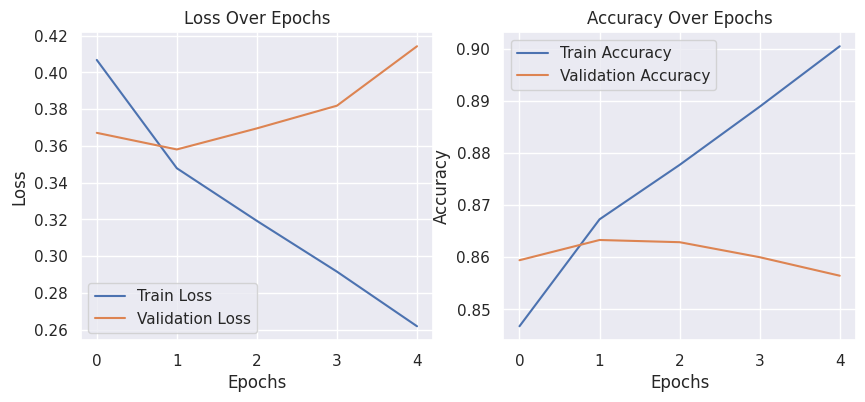

In [ ]:
# **Plot Loss**
plt.figure(figsize=(10, 4))
plt.subplot(1, 2, 1)
plt.plot(train_loss, label='Train Loss')
plt.plot(val_loss, label='Validation Loss')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.title('Loss Over Epochs')
plt.legend()

# **Plot Accuracy**
plt.subplot(1, 2, 2)
plt.plot(train_acc, label='Train Accuracy')
plt.plot(val_acc, label='Validation Accuracy')
plt.xlabel('Epochs')
plt.ylabel('Accuracy')
plt.title('Accuracy Over Epochs')
plt.legend()

plt.show()

In [ ]:
def build_and_train_bilstm(voc_size, sent_length, X_train, y_train, X_test, y_test,
                           embedding_dim=40, lstm_units=100, dropout_rate=0.3, optimizer='adam',
                           epochs=10, batch_size=32, patience=3):
    """
    Function to build, train, and evaluate a BiLSTM model with early stopping.

    Parameters:
    - voc_size: Vocabulary size
    - sent_length: Maximum sentence length
    - X_train, y_train: Training data and labels
    - X_test, y_test: Test data and labels
    - embedding_dim: Dimension of word embeddings (default=40)
    - lstm_units: Number of LSTM units (default=100)
    - dropout_rate: Dropout rate to prevent overfitting (default=0.3)
    - optimizer: Optimizer to use ('adam' or 'rmsprop', default='adam')
    - epochs: Number of training epochs (default=10)
    - batch_size: Batch size for training (default=32)
    - patience: Early stopping patience (default=3)

    Returns:
    - Trained model
    - Training history
    """

    # Build the model
    model = Sequential()
    model.add(Embedding(input_dim=voc_size, output_dim=embedding_dim, input_length=sent_length))
    model.add(Bidirectional(LSTM(lstm_units, return_sequences=False)))
    model.add(Dropout(dropout_rate))
    model.add(Dense(3, activation='softmax'))  # Assuming 3 sentiment classes

    # Compile model
    optimizer = Adam() if optimizer == 'adam' else RMSprop()
    model.compile(loss='categorical_crossentropy', optimizer=optimizer, metrics=['accuracy'])

    # Early stopping
    early_stopping = EarlyStopping(monitor='val_loss', patience=patience, restore_best_weights=True, verbose=1)

    # Train model
    history = model.fit(X_train, y_train, validation_data=(X_test, y_test),
                        epochs=epochs, batch_size=batch_size, callbacks=[early_stopping])

    # Evaluate model
    y_pred = np.argmax(model.predict(X_test), axis=1)
    y_true = np.argmax(y_test, axis=1)

    # Confusion matrix
    cm = confusion_matrix(y_true, y_pred)
    plt.figure(figsize=(6, 5))
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=['Negative', 'Neutral', 'Positive'],
                yticklabels=['Negative', 'Neutral', 'Positive'])
    plt.xlabel("Predicted")
    plt.ylabel("Actual")
    plt.title("Confusion Matrix")
    plt.show()

    # Classification report
    print("\nClassification Report:\n", classification_report(y_true, y_pred, target_names=['Negative', 'Neutral', 'Positive']))

    return model, history

Epoch 1/10
2330/2330 ━━━━━━━━━━━━━━━━━━━━ 27s 10ms/step - accuracy: 0.8223 - loss: 0.4800 - val_accuracy: 0.8589 - val_loss: 0.3719
Epoch 2/10
2330/2330 ━━━━━━━━━━━━━━━━━━━━ 42s 10ms/step - accuracy: 0.8669 - loss: 0.3516 - val_accuracy: 0.8629 - val_loss: 0.3621
Epoch 3/10
2330/2330 ━━━━━━━━━━━━━━━━━━━━ 40s 10ms/step - accuracy: 0.8777 - loss: 0.3189 - val_accuracy: 0.8640 - val_loss: 0.3621
Epoch 4/10
2330/2330 ━━━━━━━━━━━━━━━━━━━━ 23s 10ms/step - accuracy: 0.8876 - loss: 0.2943 - val_accuracy: 0.8598 - val_loss: 0.3836
Epoch 5/10
2330/2330 ━━━━━━━━━━━━━━━━━━━━ 41s 10ms/step - accuracy: 0.8994 - loss: 0.2686 - val_accuracy: 0.8558 - val_loss: 0.3953
Epoch 6/10
2330/2330 ━━━━━━━━━━━━━━━━━━━━ 47s 12ms/step - accuracy: 0.9099 - loss: 0.2412 - val_accuracy: 0.8555 - val_loss: 0.4204
Epoch 7/10
2330/2330 ━━━━━━━━━━━━━━━━━━━━ 35s 10ms/step - accuracy: 0.9196 - loss: 0.2185 - val_accuracy: 0.8438 - val_loss: 0.4674
Epoch 8/10
2330/2330 ━━━━━━━━━━━━━━━━━━━━ 42s 10ms/step - accuracy: 0.9290 -

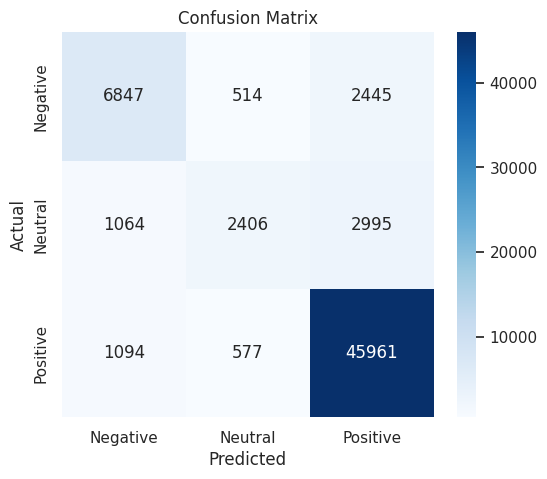


Classification Report:
               precision    recall  f1-score   support

    Negative       0.76      0.70      0.73      9806
     Neutral       0.69      0.37      0.48      6465
    Positive       0.89      0.96      0.93     47632

    accuracy                           0.86     63903
   macro avg       0.78      0.68      0.71     63903
weighted avg       0.85      0.86      0.85     63903



(<Sequential name=sequential_2, built=True>,
 <keras.src.callbacks.history.History at 0x7a7593fcb090>)

In [ ]:
build_and_train_bilstm(
    voc_size=5000,
    sent_length=100,
    X_train=X_train,
    y_train=y_train,
    X_test=X_test,
    y_test=y_test,
    embedding_dim=50,
    lstm_units=128,
    dropout_rate=0.4,
    # optimizer='rmsprop',
    epochs=10,
    batch_size=64,
    patience=5
)

Epoch 1/10
4660/4660 ━━━━━━━━━━━━━━━━━━━━ 50s 10ms/step - accuracy: 0.8289 - loss: 0.4609 - val_accuracy: 0.8611 - val_loss: 0.3687
Epoch 2/10
4660/4660 ━━━━━━━━━━━━━━━━━━━━ 47s 10ms/step - accuracy: 0.8663 - loss: 0.3484 - val_accuracy: 0.8604 - val_loss: 0.3612
Epoch 3/10
4660/4660 ━━━━━━━━━━━━━━━━━━━━ 82s 10ms/step - accuracy: 0.8791 - loss: 0.3181 - val_accuracy: 0.8628 - val_loss: 0.3625
Epoch 4/10
4660/4660 ━━━━━━━━━━━━━━━━━━━━ 83s 10ms/step - accuracy: 0.8890 - loss: 0.2923 - val_accuracy: 0.8597 - val_loss: 0.3710
Epoch 5/10
4660/4660 ━━━━━━━━━━━━━━━━━━━━ 92s 12ms/step - accuracy: 0.9015 - loss: 0.2607 - val_accuracy: 0.8585 - val_loss: 0.4011
Epoch 5: early stopping
Restoring model weights from the end of the best epoch: 2.
1997/1997 ━━━━━━━━━━━━━━━━━━━━ 7s 3ms/step


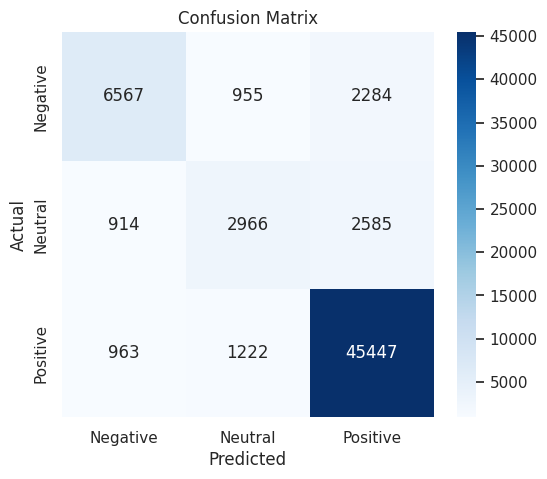


Classification Report:
               precision    recall  f1-score   support

    Negative       0.78      0.67      0.72      9806
     Neutral       0.58      0.46      0.51      6465
    Positive       0.90      0.95      0.93     47632

    accuracy                           0.86     63903
   macro avg       0.75      0.69      0.72     63903
weighted avg       0.85      0.86      0.85     63903



(<Sequential name=sequential_5, built=True>,
 <keras.src.callbacks.history.History at 0x7a758d008110>)

In [ ]:
build_and_train_bilstm(
    voc_size=5000,
    sent_length=50,
    X_train=X_train,
    y_train=y_train,
    X_test=X_test,
    y_test=y_test,
    embedding_dim=50,
    lstm_units=256,
    dropout_rate=0.3,
    optimizer='adam',
    epochs=10,
    batch_size=32,
    patience=3
)